<a href="https://colab.research.google.com/github/ogut77/DataScience/blob/main/Homework9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#First execute this cell go to Runtime and click on Restart Runtime
!pip install --upgrade --no-deps statsmodels
!pip install  StatsForecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


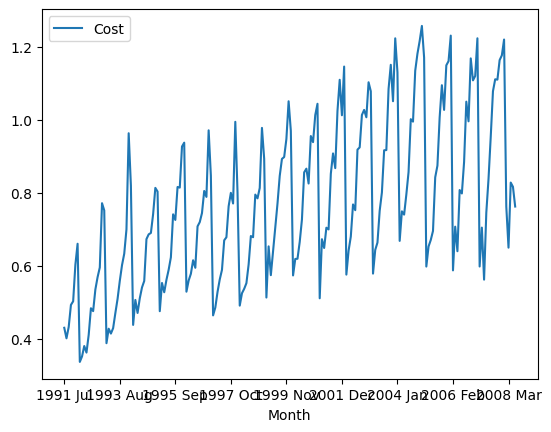

In [1]:
import pandas as pd
from matplotlib import pyplot
ap1=pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/h02.csv')
ap1=ap1.set_index('Month')
ap1.plot()
pyplot.show()


In [2]:
ap1

,Cost
Month,
1991 Jul,0.429795
1991 Aug,0.400906
1991 Sep,0.432159
1991 Oct,0.492543
1991 Nov,0.502369
...,...
2008 Feb,0.761822
2008 Mar,0.649435
2008 Apr,0.827887


Using the above data set

1)Test stationary of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

2)Take difference and seasonal difference and test stationay of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

3) Plot ACF and PACF of series if series' difference and seasonal difference taken .

4) Based on the plot of ACF and PACF, come up with two SARIMA model and compare their Akaike Information Criterion metric.

5)Split data into train and test. For the test data, use last 12 months observation.

6)Plot test, train and forecast values for the SARIMA model chosen at Q4. Evaluate performance of the model in terms of MAE(mean absulate error), MAPE(mean absulate percentage error) and MSE(Mean squared Error).

7) Using the Statsforecast library, implement the following models: AutoARIMA, AutoETS, HoltWinters,  AutoTheta, and MSTL and plot the forecast of this model .Evaluate the performance of these model model using  MSE (Mean Squared Error).Note that seasonality period is 12.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Format the index to datetime
ap1.index = pd.to_datetime(ap1.index)
ap1.index.freq = 'MS' # Month Start frequency

/tmp/ipykernel_7647/2912856234.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ap1.index = pd.to_datetime(ap1.index)


In [5]:
# 1
def print_adf_results(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

print("ADF Test on Original Series:")
print_adf_results(ap1['Cost'])

# Because the p-value of 0.4328 is significantly greater than the 0.05 threshold, we fail to reject the null hypothesis.
# This means that our original time series is non-stationary (it has a unit root), confirming that we must apply differencing to stabilize its mean
# before fitting forecasting models.

ADF Test on Original Series:
ADF Statistic: -1.6968
p-value: 0.4328


ADF Test on Differenced Series:
ADF Statistic: -5.0704
p-value: 0.0000


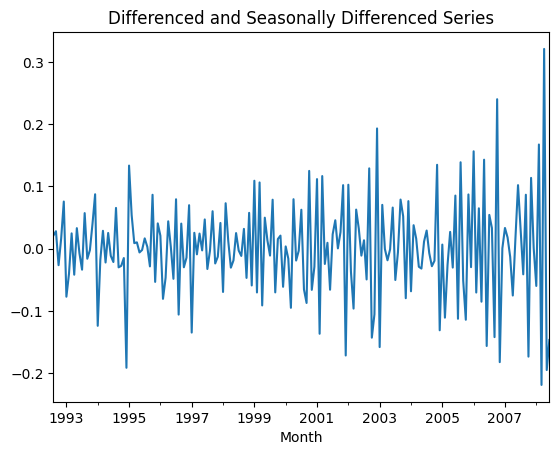

In [6]:
# 2

# Take first difference, then seasonal difference (period 12)
df_diff = ap1['Cost'].diff().diff(12).dropna()

print("ADF Test on Differenced Series:")
print_adf_results(df_diff)

df_diff.plot(title="Differenced and Seasonally Differenced Series")
plt.show()

# With a p-value of 0.0000, which is well below the 0.05 significance level, we reject the null hypothesis.
# Therefore, the differenced and seasonally differenced series is now stationary and suitable for modeling.

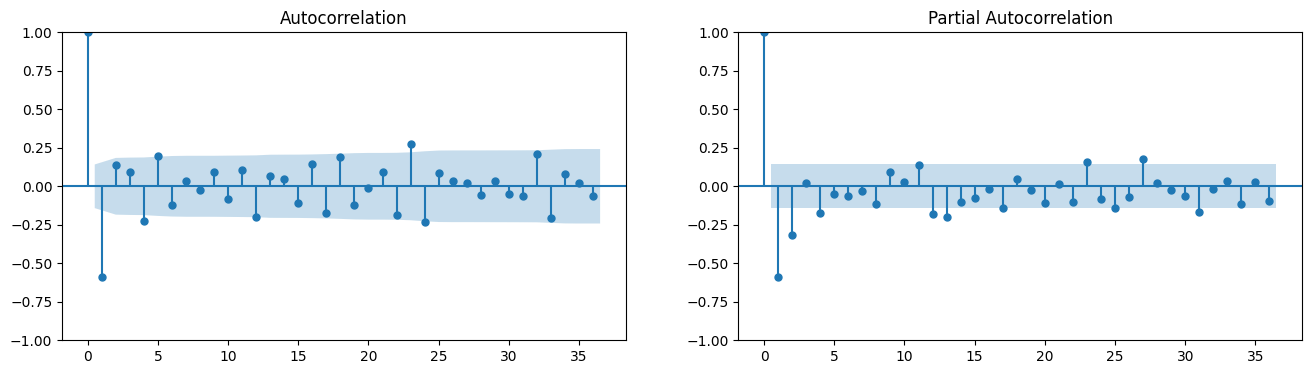

Model 1 AIC: -555.88
Model 2 AIC: -552.33


In [7]:
# 3
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_diff, lags=36, ax=axes[0])
plot_pacf(df_diff, lags=36, ax=axes[1])
plt.show()

# 4
# Model 1
model1 = SARIMAX(ap1['Cost'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
results1 = model1.fit(disp=False)
print(f'Model 1 AIC: {results1.aic:.2f}')

# Model 2
model2 = SARIMAX(ap1['Cost'], order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
results2 = model2.fit(disp=False)
print(f'Model 2 AIC: {results2.aic:.2f}')

In [8]:
# 5
test_size = 12
train = ap1.iloc[:-test_size]
test = ap1.iloc[-test_size:]

SARIMA MAE: 0.0754
SARIMA MAPE: 0.0859
SARIMA MSE: 0.0094


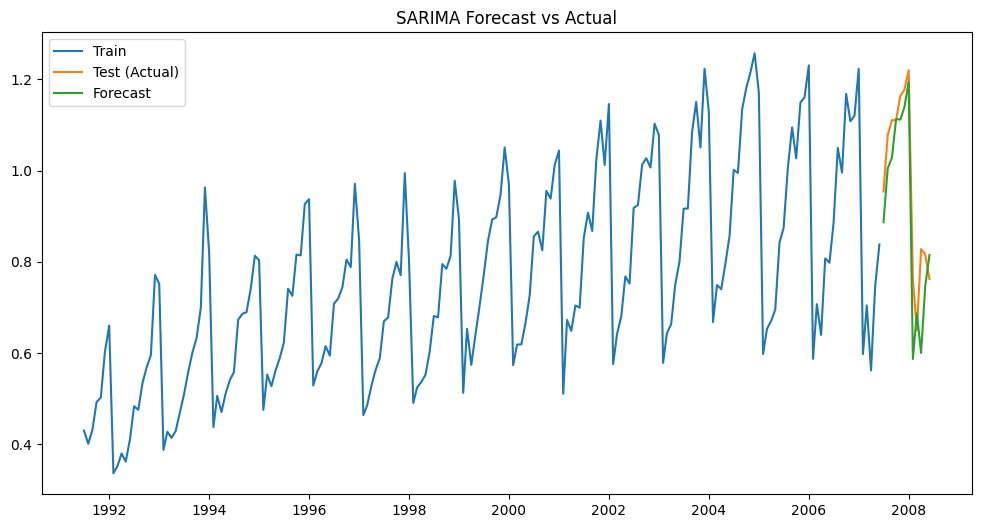

In [9]:
# 6

# Fit model on training data
best_model = SARIMAX(train['Cost'], order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
best_results = best_model.fit(disp=False)

# 12 months forecast
forecast = best_results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean

# Metrics
mae = mean_absolute_error(test['Cost'], forecast_mean)
mape = mean_absolute_percentage_error(test['Cost'], forecast_mean)
mse = mean_squared_error(test['Cost'], forecast_mean)

print(f'SARIMA MAE: {mae:.4f}')
print(f'SARIMA MAPE: {mape:.4f}')
print(f'SARIMA MSE: {mse:.4f}')

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Cost'], label='Train')
plt.plot(test.index, test['Cost'], label='Test (Actual)')
plt.plot(test.index, forecast_mean, label='Forecast')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()

Mean Squared Error (MSE)
AutoARIMA: 0.008327
AutoETS: 0.007230
HoltWinters: 0.009044
AutoTheta: 0.007918
MSTL: 0.006967


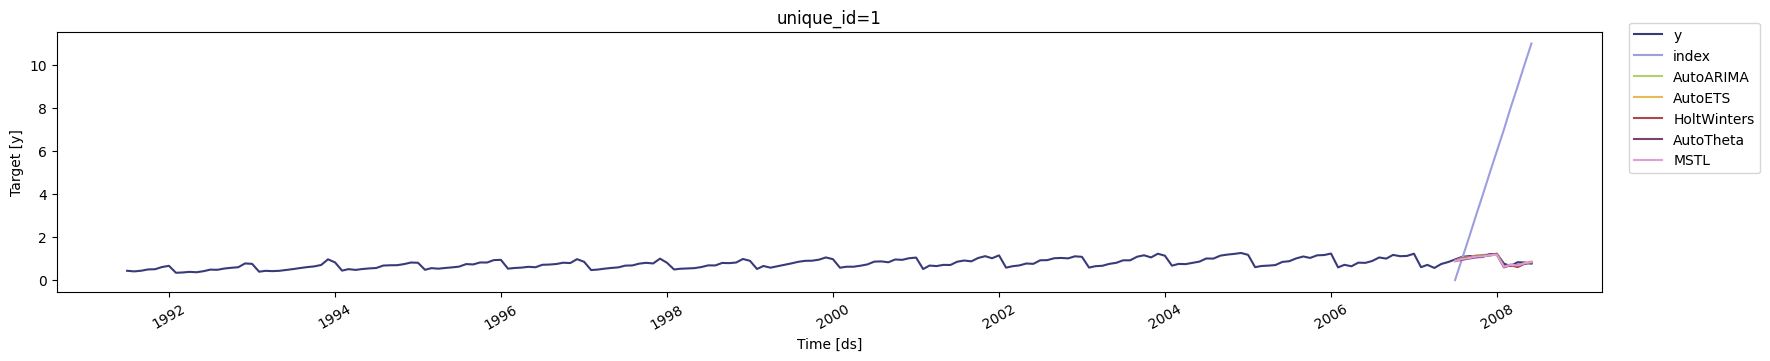

In [12]:
# 7
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, HoltWinters, AutoTheta, MSTL
from sklearn.metrics import mean_squared_error

# Dataframe for StatsForecast
sf_df = ap1.reset_index()
sf_df.columns = ['ds', 'y']
sf_df['unique_id'] = 1 # Required by StatsForecast

sf_train = sf_df.iloc[:-test_size]
sf_test = sf_df.iloc[-test_size:]

# Models (seasonality period is 12)
models = [
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    HoltWinters(season_length=12),
    AutoTheta(season_length=12),
    MSTL(season_length=12, trend_forecaster=AutoARIMA())
]

# Initialization of StatsForecast
sf = StatsForecast(
    models=models,
    freq='MS',
    n_jobs=-1
)

# Generation of forecasts
forecasts_df = sf.forecast(h=12, df=sf_train)
forecasts_df = forecasts_df.reset_index()

# MSE for each model
print("Mean Squared Error (MSE)")
for model_name in ['AutoARIMA', 'AutoETS', 'HoltWinters', 'AutoTheta', 'MSTL']:
    model_mse = mean_squared_error(sf_test['y'], forecasts_df[model_name])
    print(f'{model_name}: {model_mse:.6f}')

# Plotting the results using StatsForecast's built-in plotter
sf.plot(sf_df, forecasts_df)